In [1]:
import sys
!{sys.executable} -m pip install catboost
print(" CatBoost installed!")

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---

In [2]:
# TASK 4: Loan Default Risk + Business Cost Optimization
# Goal: Predict loan default + find best decision threshold
# Models: Logistic Regression + CatBoost

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# CatBoost
from catboost import CatBoostClassifier

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [3]:
# CREATE REALISTIC LOAN DATASET 
# Simulating Home Credit style loan default data
# Features that affect loan default in real life

np.random.seed(42)
n = 5000    # 5000 loan applications

# Generate base features
age           = np.random.randint(20, 65, n)
income        = np.random.randint(15000, 120000, n)
loan_amount   = np.random.randint(5000, 50000, n)
loan_term     = np.random.choice([12, 24, 36, 48, 60], n)  # months
credit_score  = np.random.randint(300, 850, n)
employment    = np.random.choice(
    ['Employed', 'Self-Employed', 'Unemployed', 'Retired'], n,
    p=[0.55, 0.25, 0.12, 0.08]
)
education     = np.random.choice(
    ['High School', 'Bachelor', 'Master', 'PhD'], n,
    p=[0.35, 0.40, 0.18, 0.07]
)
marital       = np.random.choice(
    ['Single', 'Married', 'Divorced'], n,
    p=[0.35, 0.50, 0.15]
)
num_defaults  = np.random.randint(0, 4, n)    # Past defaults
debt_ratio    = np.random.uniform(0.1, 0.9, n) # Debt to income ratio

# Generate target (default = 1, no default = 0)
# Logic: Higher credit score + income = less likely to default
default_prob = (
    0.3
    - (credit_score - 300) / 550 * 0.3    # Higher score → less default
    - (income - 15000) / 105000 * 0.2     # Higher income → less default
    + debt_ratio * 0.25                    # Higher debt → more default
    + num_defaults * 0.08                  # Past defaults → more default
    + (employment == 'Unemployed') * 0.2   # Unemployed → more default
)

# Clip probability between 0 and 1
default_prob = np.clip(default_prob, 0.05, 0.95)

# Generate binary target based on probability
target = np.array([
    np.random.binomial(1, p) for p in default_prob
])

# Build DataFrame
df = pd.DataFrame({
    'Age'          : age,
    'Income'       : income,
    'LoanAmount'   : loan_amount,
    'LoanTerm'     : loan_term,
    'CreditScore'  : credit_score,
    'Employment'   : employment,
    'Education'    : education,
    'MaritalStatus': marital,
    'PastDefaults' : num_defaults,
    'DebtRatio'    : debt_ratio.round(3),
    'Default'      : target                # 1=defaulted, 0=repaid
})

print("Dataset created!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDefault Distribution:")
print(df['Default'].value_counts())
print(f"\nDefault Rate: {df['Default'].mean()*100:.1f}%")

Dataset created!
Shape: (5000, 11)

First 5 rows:
   Age  Income  LoanAmount  LoanTerm  CreditScore     Employment    Education  \
0   58   52842       18266        36          449       Employed     Bachelor   
1   48   28900       21940        36          437       Employed       Master   
2   34   95059       29003        36          434       Employed  High School   
3   62   16881       37872        24          756  Self-Employed  High School   
4   27   48037       39815        60          793     Unemployed       Master   

  MaritalStatus  PastDefaults  DebtRatio  Default  
0        Single             2      0.378        0  
1        Single             0      0.228        1  
2       Married             0      0.733        0  
3       Married             1      0.475        1  
4        Single             2      0.464        1  

Default Distribution:
Default
0    3350
1    1650
Name: count, dtype: int64

Default Rate: 33.0%


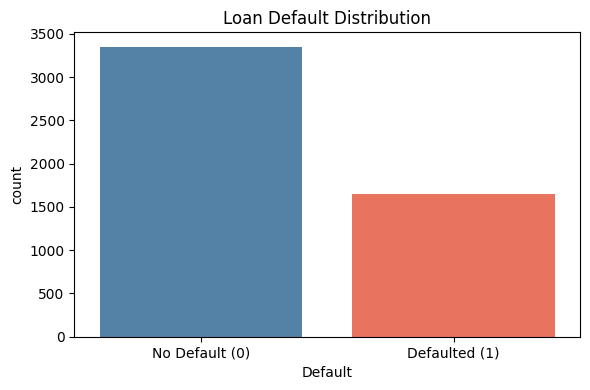

In [10]:
# EXPLORATORY DATA ANALYSIS

# --- Plot 1: Default Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Default',
              hue='Default',
              palette={0:'steelblue', 1:'tomato'},
              legend=False)
plt.title('Loan Default Distribution')
plt.xticks([0, 1], ['No Default (0)', 'Defaulted (1)'])
plt.tight_layout()
plt.show()

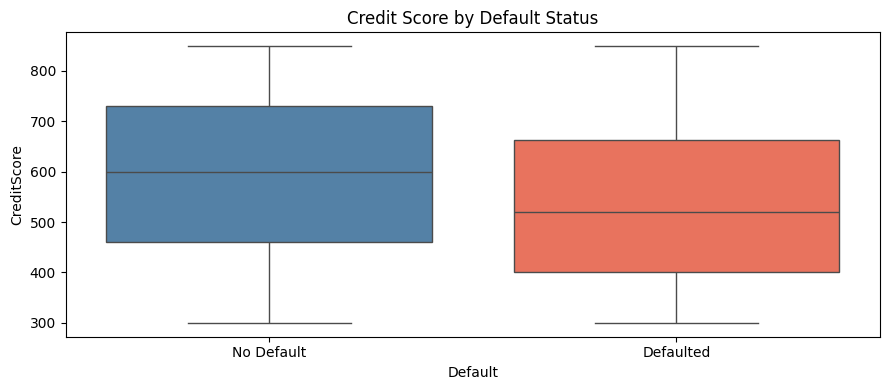

In [11]:
# --- Plot 2: Credit Score vs Default ---
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='Default', y='CreditScore',
            hue='Default',
            palette={0:'steelblue', 1:'tomato'},
            legend=False)
plt.title('Credit Score by Default Status')
plt.xticks([0, 1], ['No Default', 'Defaulted'])
plt.tight_layout()
plt.show()

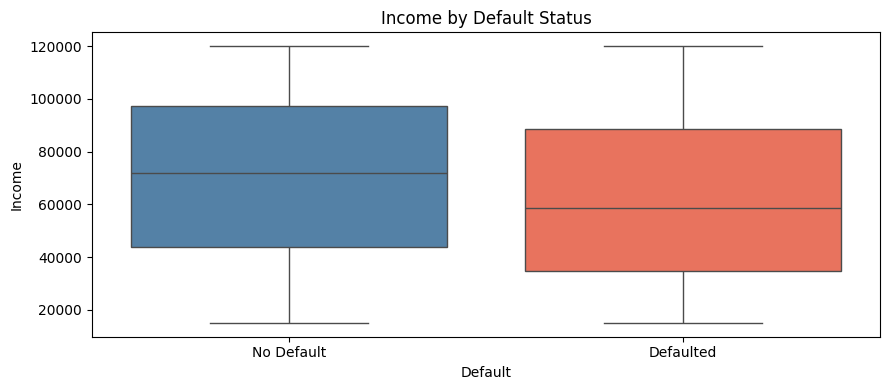

In [12]:
# --- Plot 3: Income vs Default ---
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='Default', y='Income',
            hue='Default',
            palette={0:'steelblue', 1:'tomato'},
            legend=False)
plt.title('Income by Default Status')
plt.xticks([0, 1], ['No Default', 'Defaulted'])
plt.tight_layout()
plt.show()

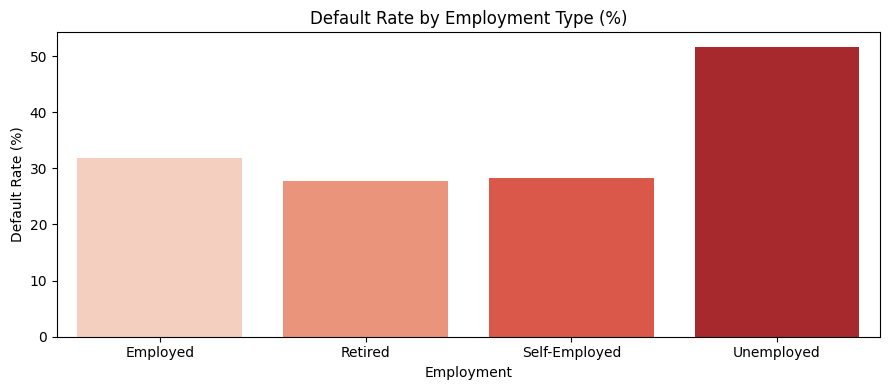

In [13]:
# --- Plot 4: Employment vs Default Rate ---
plt.figure(figsize=(9, 4))
emp_default = df.groupby('Employment')['Default'].mean() * 100
sns.barplot(x=emp_default.index, y=emp_default.values,
            hue=emp_default.index,
            palette='Reds', legend=False)
plt.title('Default Rate by Employment Type (%)')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

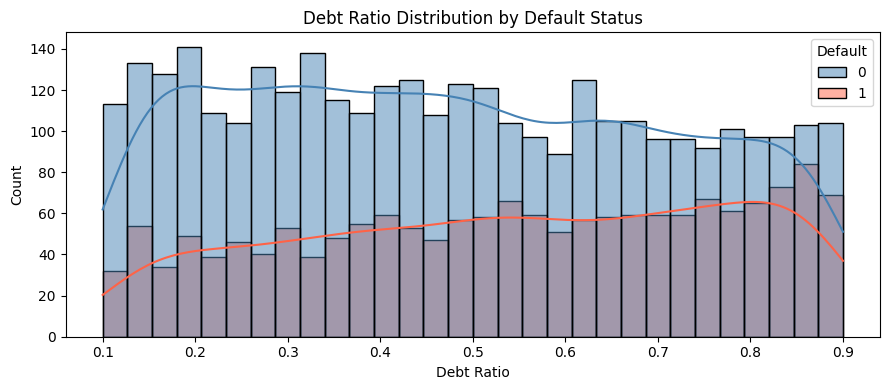

In [14]:
# --- Plot 5: Debt Ratio vs Default ---
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='DebtRatio', hue='Default',
             bins=30, kde=True,
             palette={0:'steelblue', 1:'tomato'})
plt.title('Debt Ratio Distribution by Default Status')
plt.xlabel('Debt Ratio')
plt.tight_layout()
plt.show()

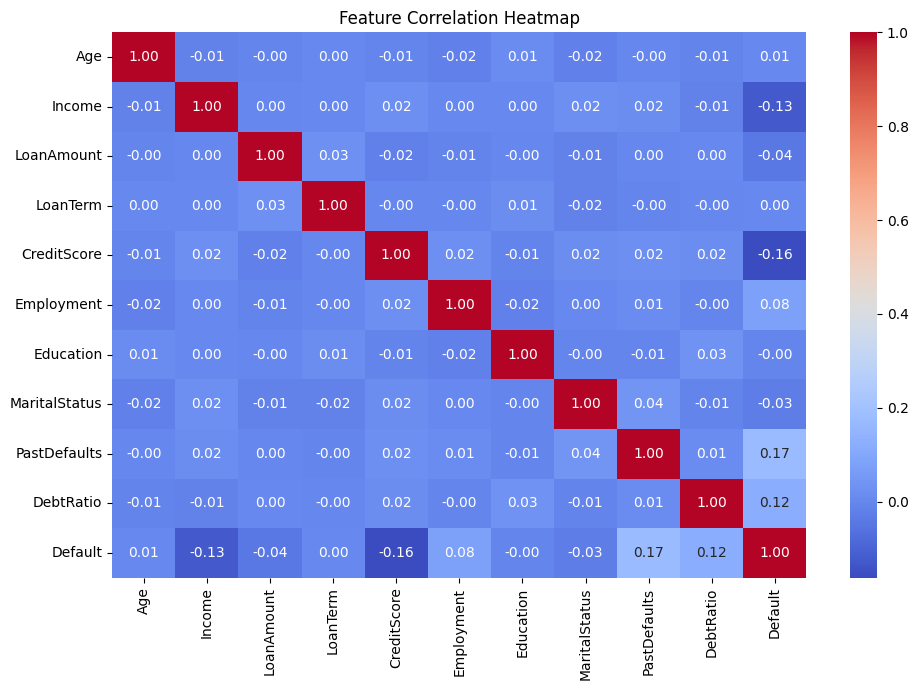

In [15]:
# --- Plot 6: Correlation Heatmap ---
df_corr = df.copy()
le_temp  = LabelEncoder()
for col in ['Employment', 'Education', 'MaritalStatus']:
    df_corr[col] = le_temp.fit_transform(df_corr[col])

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(), annot=True,
            cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
# PREPROCESSING 

df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['Employment', 'Education', 'MaritalStatus']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"Encoded: {col}")

# Split features and target
X = df_model.drop('Default', axis=1)
y = df_model['Default']

# Train/Test split — stratified to keep default ratio same
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Keep same default% in train & test
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train default rate: {y_train.mean()*100:.1f}%")
print(f"Test default rate:  {y_test.mean()*100:.1f}%")

# Scale for Logistic Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\nPreprocessing complete!")

Encoded: Employment
Encoded: Education
Encoded: MaritalStatus

Train size: (4000, 10)
Test size:  (1000, 10)
Train default rate: 33.0%
Test default rate:  33.0%

Preprocessing complete!


In [17]:
#  MODEL 1 — LOGISTIC REGRESSION

print("Training Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'     # Handle imbalanced classes
)
lr.fit(X_train_sc, y_train)
y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]  # Probability of default

print("\nLOGISTIC REGRESSION RESULTS:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Training Logistic Regression...

LOGISTIC REGRESSION RESULTS:
Accuracy : 0.6270
F1 Score : 0.5212
ROC AUC  : 0.6862

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.63      0.69       670
           1       0.45      0.62      0.52       330

    accuracy                           0.63      1000
   macro avg       0.61      0.62      0.61      1000
weighted avg       0.66      0.63      0.64      1000



In [19]:
# MODEL 2 — CATBOOST 
# CatBoost = Gradient Boosting by Yandex

print("Training CatBoost... (may take 1-2 minutes)")

cat_model = CatBoostClassifier(
    iterations=500,         # Number of trees
    learning_rate=0.05,     # How fast it learns
    depth=6,                # Tree depth
    random_seed=42,
    auto_class_weights='Balanced',  # Handle imbalance
    verbose=100             # Print progress every 100 iterations
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),   # Monitor test performance
    early_stopping_rounds=50     # Stop if no improvement for 50 rounds
)

y_pred_cat  = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

print("\nCATBOOST RESULTS:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_cat, zero_division=0):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba_cat):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat, zero_division=0))

Training CatBoost... (may take 1-2 minutes)
0:	learn: 0.6876345	test: 0.6881046	best: 0.6881046 (0)	total: 5.68ms	remaining: 2.83s
100:	learn: 0.5608673	test: 0.6240802	best: 0.6240802 (100)	total: 396ms	remaining: 1.56s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6227299854
bestIteration = 115

Shrink model to first 116 iterations.

CATBOOST RESULTS:
Accuracy : 0.6400
F1 Score : 0.5349
ROC AUC  : 0.7039

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.65      0.71       670
           1       0.47      0.63      0.53       330

    accuracy                           0.64      1000
   macro avg       0.62      0.64      0.62      1000
weighted avg       0.68      0.64      0.65      1000



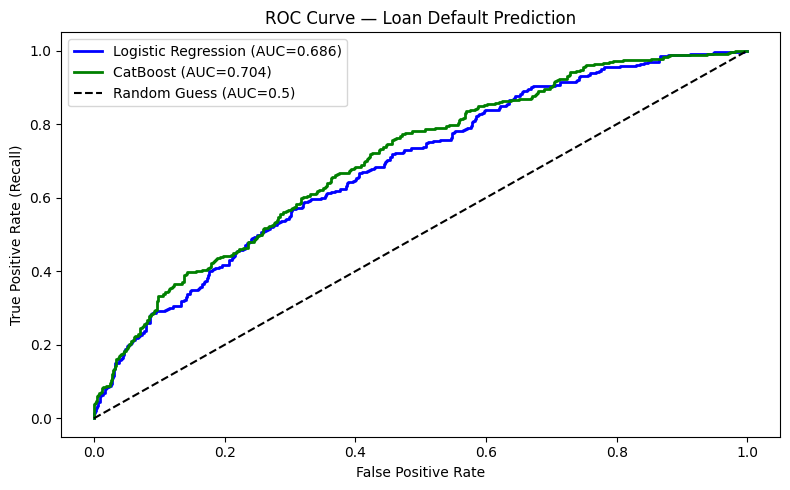

LR  AUC: 0.6862
CatBoost AUC: 0.7039

Better Model: CatBoost


In [20]:
# ROC CURVE COMPARISON 

plt.figure(figsize=(8, 5))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={auc_lr:.3f})',
         color='blue', linewidth=2)

# CatBoost ROC
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
auc_cat = roc_auc_score(y_test, y_proba_cat)
plt.plot(fpr_cat, tpr_cat,
         label=f'CatBoost (AUC={auc_cat:.3f})',
         color='green', linewidth=2)

# Baseline
plt.plot([0,1],[0,1],'k--', label='Random Guess (AUC=0.5)')

plt.title('ROC Curve — Loan Default Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"LR  AUC: {auc_lr:.4f}")
print(f"CatBoost AUC: {auc_cat:.4f}")
best = 'CatBoost' if auc_cat > auc_lr else 'Logistic Regression'
print(f"\nBetter Model: {best}")

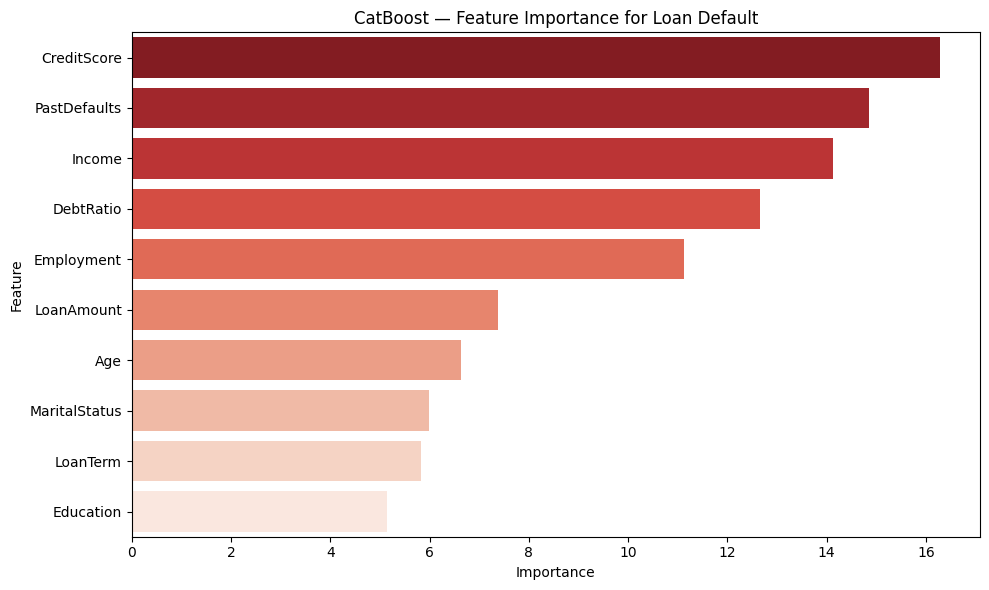

Top 5 most important features:
        Feature  Importance
4   CreditScore   16.277287
8  PastDefaults   14.858920
1        Income   14.120713
9     DebtRatio   12.666413
5    Employment   11.119843


In [21]:
# FEATURE IMPORTANCE

feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature',
            hue='Feature', palette='Reds_r', legend=False)
plt.title('CatBoost — Feature Importance for Loan Default')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_imp.head())
# INSIGHT: CreditScore, DebtRatio, Income are usually top features

In [22]:
#  THRESHOLD OPTIMIZATION
# This is what makes Task 4 UNIQUE and ADVANCED
#
# Normal models predict at threshold = 0.5
# But in banking, costs are NOT equal:
#
#   False Negative (approve bad loan)  → Bank loses $10,000
#   False Positive (reject good loan)  → Bank loses $500
#
# So we try different thresholds and find which one
# minimizes TOTAL BUSINESS COST

# ── Define Business Costs

COST_FALSE_NEGATIVE = 10000   # Approved a defaulter → big loss
COST_FALSE_POSITIVE = 500     # Rejected a good customer → small loss

print("Business Cost Structure:")
print(f"  False Negative (miss a defaulter): ${COST_FALSE_NEGATIVE:,}")
print(f"  False Positive (reject good loan): ${COST_FALSE_POSITIVE:,}")
print()

# ── Try thresholds from 0.1 to 0.9
thresholds   = np.arange(0.1, 0.91, 0.05)
total_costs  = []
fn_counts    = []
fp_counts    = []

for threshold in thresholds:
    # Apply threshold to probabilities
    y_pred_thresh = (y_proba_cat >= threshold).astype(int)

    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()

    # Calculate total business cost
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)

    total_costs.append(total_cost)
    fn_counts.append(fn)
    fp_counts.append(fp)

# Find optimal threshold
optimal_idx       = np.argmin(total_costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost      = total_costs[optimal_idx]

print(f" Optimal Threshold : {optimal_threshold:.2f}")
print(f" Minimum Total Cost: ${optimal_cost:,}")
print(f"   (vs default 0.5 cost: ${total_costs[list(thresholds).index(min(thresholds, key=lambda x: abs(x-0.5)))]:,})")

Business Cost Structure:
  False Negative (miss a defaulter): $10,000
  False Positive (reject good loan): $500

 Optimal Threshold : 0.10
 Minimum Total Cost: $332,000
   (vs default 0.5 cost: $1,348,500)


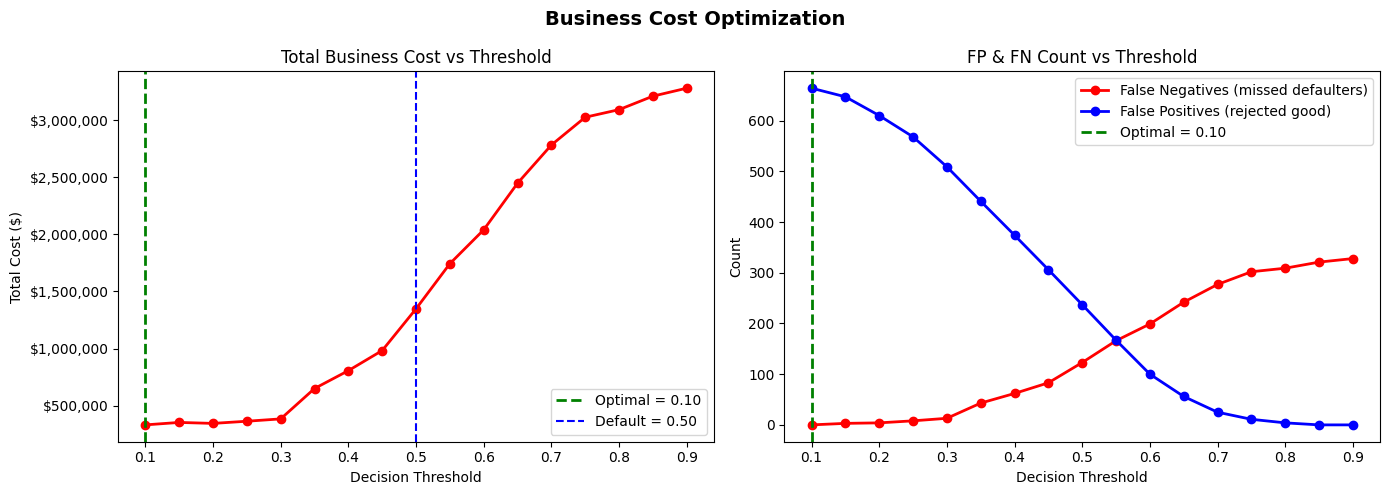

In [23]:
# VISUALIZE COST OPTIMIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Cost vs Threshold
axes[0].plot(thresholds, total_costs,
             'ro-', linewidth=2, markersize=6)
axes[0].axvline(x=optimal_threshold, color='green',
                linestyle='--', linewidth=2,
                label=f'Optimal = {optimal_threshold:.2f}')
axes[0].axvline(x=0.5, color='blue',
                linestyle='--', linewidth=1.5,
                label='Default = 0.50')
axes[0].set_title('Total Business Cost vs Threshold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# Plot 2: FP and FN counts vs Threshold
axes[1].plot(thresholds, fn_counts,
             'r-o', label='False Negatives (missed defaulters)',
             linewidth=2)
axes[1].plot(thresholds, fp_counts,
             'b-o', label='False Positives (rejected good)',
             linewidth=2)
axes[1].axvline(x=optimal_threshold, color='green',
                linestyle='--', linewidth=2,
                label=f'Optimal = {optimal_threshold:.2f}')
axes[1].set_title('FP & FN Count vs Threshold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Business Cost Optimization', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.show()

RESULTS AT OPTIMAL THRESHOLD = 0.10

True Positives  (caught defaulters): 330
True Negatives  (approved good):      6
False Positives (rejected good):      664
False Negatives (missed defaulters):  0

F1 Score    : 0.4985
Accuracy    : 0.3360

Total Cost at Optimal Threshold : $332,000


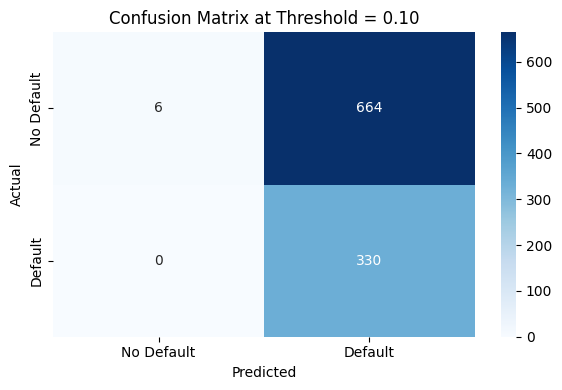

In [24]:
#  FINAL RESULTS AT OPTIMAL THRESHOLD 

print("=" * 55)
print(f"RESULTS AT OPTIMAL THRESHOLD = {optimal_threshold:.2f}")
print("=" * 55)

# Apply optimal threshold
y_pred_optimal = (y_proba_cat >= optimal_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

print(f"\nTrue Positives  (caught defaulters): {tp}")
print(f"True Negatives  (approved good):      {tn}")
print(f"False Positives (rejected good):      {fp}")
print(f"False Negatives (missed defaulters):  {fn}")

print(f"\nF1 Score    : {f1_score(y_test, y_pred_optimal, zero_division=0):.4f}")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_optimal):.4f}")

# Cost comparison
cost_default  = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
print(f"\nTotal Cost at Optimal Threshold : ${cost_default:,}")

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimal),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
plt.title(f'Confusion Matrix at Threshold = {optimal_threshold:.2f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

